In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import joblib
import os
import sys
sys.path.append("..")

from src.snn_model import BRICSLiquiditySNN
from src.train_utils import train_one_epoch, evaluate, save_model

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print("✅ Imports done")

PyTorch : 2.10.0+cpu
Device  : cpu
✅ Imports done


#### Load same data with same scaler

In [19]:
# ── Load splits ───────────────────────────────────────────────────────
train_raw = pd.read_csv("../data/processed/train_features.csv",
                         index_col="date", parse_dates=True)
val_raw   = pd.read_csv("../data/processed/val_features.csv",
                         index_col="date", parse_dates=True)

TARGET_COL   = "target"
FEATURE_COLS = [c for c in train_raw.columns if c != TARGET_COL]
N_FEATURES   = len(FEATURE_COLS)
LOOKBACK     = 10
BATCH_SIZE   = 32

train_clean = train_raw[FEATURE_COLS + [TARGET_COL]].dropna()
val_clean   = val_raw[FEATURE_COLS + [TARGET_COL]].dropna()

# ── Load the SAME scaler fitted on train in Month 2 Day 1 ─────────────
# Critical: using the same scaler guarantees identical preprocessing.
# A different scaler would make the comparison unfair.
scaler_path = "../outputs/scaler.pkl"
scaler      = joblib.load(scaler_path)

X_train = scaler.transform(
    train_clean[FEATURE_COLS].values.astype(np.float32))
y_train = train_clean[TARGET_COL].values.astype(np.float32)

X_val   = scaler.transform(
    val_clean[FEATURE_COLS].values.astype(np.float32))
y_val   = val_clean[TARGET_COL].values.astype(np.float32)

print(f"Train  : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Scaler : loaded from {scaler_path}  ← same as SNN training")
print(f"Feature range check:")
print(f"  Train [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  Val   [{X_val.min():.3f},  {X_val.max():.3f}]")

Train  : (1088, 9)  |  Val : (364, 9)
Scaler : loaded from ../outputs/scaler.pkl  ← same as SNN training
Feature range check:
  Train [0.000, 1.000]
  Val   [0.000,  1.000]


#### TimeSeriesDataset (reuse from src)

In [20]:
# Reuse the same Dataset class — identical to what SNN used
# This guarantees the same sequences, same ordering, same labels

class TimeSeriesDataset(torch.utils.data.Dataset):
    """
    Sliding window dataset for time series sequences.
    Identical to the class used for SNN training — ensures fair comparison.
    """
    def __init__(self, features, targets, lookback=10):
        self.features      = torch.tensor(features, dtype=torch.float32)
        self.targets       = torch.tensor(targets,  dtype=torch.float32)
        self.lookback      = lookback
        self.valid_indices = list(range(lookback, len(features)))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]
        return self.features[t - self.lookback : t], self.targets[t]


train_ds = TimeSeriesDataset(X_train, y_train, LOOKBACK)
val_ds   = TimeSeriesDataset(X_val,   y_val,   LOOKBACK)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences : {len(train_ds)}")
print(f"Val sequences   : {len(val_ds)}")
print(f"Batch shape     : ({BATCH_SIZE}, {LOOKBACK}, {N_FEATURES})")
print(f"Shuffle         : False  ← same as SNN, time order preserved")

Train sequences : 1078
Val sequences   : 354
Batch shape     : (32, 10, 9)
Shuffle         : False  ← same as SNN, time order preserved


#### LSTM Architecture

In [21]:
class BRICSLiquidityLSTM(nn.Module):
    """
    LSTM baseline for INR/BRL settlement direction prediction.

    Used as the benchmark against which BRICSLiquiditySNN is compared.
    Deliberately kept simple — one LSTM layer, one dropout, one linear
    output. This is the standard time-series classification baseline
    in financial ML literature.

    Architecture
    ------------
    Input (batch, T, F) --> batch = 32, T = LOOKBACK (10), F = n_features (9 here)
        ↓
    LSTM(input_size=F, hidden_size=32, num_layers=1, batch_first=True)
        ↓  outputs (batch, T, 32) — one hidden vector per timestep
    Take last timestep: lstm_out[:, -1, :]  → (batch, 32)
        ↓
    Dropout(0.2)   — regularisation, prevents overfitting
        ↓
    Linear(32 → 1)
        ↓
    Raw logit  →  BCEWithLogitsLoss during training
               →  sigmoid > optimal_threshold for inference

    Design decisions
    ----------------
    - hidden_size=32: matches SNN hidden2 (32) for parameter fairness
    - num_layers=1: single layer — dataset too small for stacking
    - batch_first=True: input shape (batch, T, F) — same as SNN input
    - last timestep only: standard for sequence classification
      (alternative: mean pooling over all timesteps — not used here)
    - No attention, no bidirectional: this is a baseline, not SOTA

    Parameters
    ----------
    n_features  : int   — number of input features per timestep
    hidden_size : int   — LSTM hidden state dimension (default 32)
    dropout     : float — dropout rate after LSTM (default 0.2)
    num_layers  : int   — number of stacked LSTM layers (default 1)

    Input / Output
    --------------
    forward(x) input  : (batch, timesteps, n_features)
    forward(x) output : (batch, 1) — raw logit
    """

    def __init__(self,
                 n_features  : int   = 9,
                 hidden_size : int   = 32,
                 dropout     : float = 0.2,
                 num_layers  : int   = 1):
        super().__init__()

        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── Layers ────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,    # input: (batch, T, features) => batch means batch size, T means sequence length, feature means number of features
            dropout     = 0.0,     # inter-layer dropout (only for >1 layer)
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

        self._init_weights()

    def _init_weights(self):
        """
        Orthogonal initialisation for LSTM weights.

        Orthogonal init is the recommended initialisation for RNNs —
        it prevents vanishing/exploding gradients at initialisation
        and is standard in time-series ML literature.
        """
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:              # weight_ih = input-to-hidden weights
                nn.init.xavier_uniform_(param.data)  # Xavier init balances variance of activations and gradients
            elif "weight_hh" in name:           # weight_hh = hidden-to-hidden weights
                nn.init.orthogonal_(param.data) # Orthogonal init helps preserve gradient flow through time (important in RNN/LSTM)
            elif "bias" in name:
                nn.init.zeros_(param.data)
                # Set forget gate bias to 1.0 — standard LSTM trick
                # Prevents forgetting at the start of training
                n = param.size(0)
                param.data[n//4 : n//2].fill_(1.0)

        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through LSTM.

        Parameters
        ----------
        x : torch.Tensor, shape (batch, timesteps, n_features)

        Returns
        -------
        torch.Tensor, shape (batch, 1) — raw logit
        """
        # lstm_out : (batch, T, hidden_size) — output at each timestep
        # _        : (h_n, c_n) final hidden and cell states (not used)
        lstm_out, _ = self.lstm(x)

        # Take only the last timestep's output
        # lstm_out[:, -1, :] shape: (batch, hidden_size)
        out = lstm_out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)          # (batch, 1) raw logit
        return out

    def count_parameters(self) -> int:
        """Return total number of trainable parameters. 
         (Intution: This function counts how many learnable numbers the model has in total. eg:weight/bias in each layer. This is important for comparing model complexity and capacity.)"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)  # self.parameters()=> returns every parameter ; p.requires_grad => checks whether the parameter is trainable ; p.numel() => number of elements in the parameter tensor

    def flops_per_inference(self) -> int:  
        """
        Intution: FLOPs (Floating Point Operations) is a measure of computational complexity. 
            This function estimates how many basic operations (like multiplications and additions) the model performs when making a single prediction (inference) on one sequence of data. 
            This is important for understanding the efficiency of the model, especially in real-time applications.

        Estimate FLOPs per inference (one sequence, batch=1).

        LSTM FLOPs per timestep:
            4 gates × 2 × (hidden_size × n_features + hidden_size²)
            The factor 2 accounts for multiply + add per operation.

        Returns
        -------
        int — approximate FLOPs for one sequence of length LOOKBACK
        """
        flops_per_step = (
            4 * 2 * (self.hidden_size * self.n_features) +
            4 * 2 * (self.hidden_size * self.hidden_size)
        )
        return flops_per_step * LOOKBACK


print("✅ BRICSLiquidityLSTM defined")

✅ BRICSLiquidityLSTM defined


#### Snaity check:ForwardPass

In [22]:
lstm_model = BRICSLiquidityLSTM(
    n_features  = N_FEATURES,
    hidden_size = 32,
    dropout     = 0.2,
    num_layers  = 1,
).to(DEVICE)

# One batch
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(DEVICE)

print(f"Input  shape : {tuple(X_batch.shape)}  (batch, timesteps, features)")

lstm_model.eval()
with torch.no_grad():
    output = lstm_model(X_batch)

print(f"Output shape : {tuple(output.shape)}  (batch, 1)")
print(f"Output range : [{output.min().item():.4f}, {output.max().item():.4f}]")
print(f"Output std   : {output.std().item():.4f}  "
      f"(>0.01 = model outputs vary across samples ✅)")

assert tuple(output.shape) == (X_batch.shape[0], 1), "Shape mismatch"
print("\n✅ Forward pass verified")

Input  shape : (32, 10, 9)  (batch, timesteps, features)
Output shape : (32, 1)  (batch, 1)
Output range : [-0.1312, -0.0480]
Output std   : 0.0192  (>0.01 = model outputs vary across samples ✅)

✅ Forward pass verified


#### Parameter comparision: SNN vs LSTM

In [23]:
# ── Rebuild SNN for comparison ────────────────────────────────────────
snn_model = BRICSLiquiditySNN(
    n_features  = N_FEATURES,
    hidden1     = 64,
    hidden2     = 32,
    tau         = 2.0,
    v_threshold = 0.1,
).to(DEVICE)

# ── Parameter breakdown ───────────────────────────────────────────────
def param_breakdown(model, name):
    total = 0
    rows  = []
    for n, p in model.named_parameters():
        if p.requires_grad:
            count = p.numel()
            total += count
            rows.append((n, list(p.shape), count))
    return rows, total

snn_rows, snn_total = param_breakdown(snn_model, "SNN")
lstm_rows, lstm_total = param_breakdown(lstm_model, "LSTM")

print("=" * 65)
print("PARAMETER COMPARISON — SNN vs LSTM")
print("=" * 65)

print(f"\n{'SNN — BRICSLiquiditySNN'}")
print(f"  {'Layer':<30} {'Shape':>20}  {'Params':>8}")
print(f"  {'─'*60}")
for n, shape, count in snn_rows:
    print(f"  {n:<30} {str(shape):>20}  {count:>8}")
print(f"  {'─'*60}")
print(f"  {'TOTAL':<30} {'':>20}  {snn_total:>8}")

print(f"\n{'LSTM — BRICSLiquidityLSTM'}")
print(f"  {'Layer':<30} {'Shape':>20}  {'Params':>8}")
print(f"  {'─'*60}")
for n, shape, count in lstm_rows:
    print(f"  {n:<30} {str(shape):>20}  {count:>8}")
print(f"  {'─'*60}")
print(f"  {'TOTAL':<30} {'':>20}  {lstm_total:>8}")

print(f"\n{'─'*65}")
print(f"  SNN parameters  : {snn_total:>6}")
print(f"  LSTM parameters : {lstm_total:>6}")
print(f"  Ratio           : LSTM has {lstm_total/snn_total:.2f}x "
      f"{'more' if lstm_total > snn_total else 'fewer'} parameters than SNN")
print("=" * 65)

PARAMETER COMPARISON — SNN vs LSTM

SNN — BRICSLiquiditySNN
  Layer                                         Shape    Params
  ────────────────────────────────────────────────────────────
  fc1.weight                                  [64, 9]       576
  fc1.bias                                       [64]        64
  bn1.weight                                     [64]        64
  bn1.bias                                       [64]        64
  fc2.weight                                 [32, 64]      2048
  fc2.bias                                       [32]        32
  bn2.weight                                     [32]        32
  bn2.bias                                       [32]        32
  fc3.weight                                  [1, 32]        32
  fc3.bias                                        [1]         1
  ────────────────────────────────────────────────────────────
  TOTAL                                                    2945

LSTM — BRICSLiquidityLSTM
  Layer            

#### Compute comparision table

In [24]:
import json

# Load SNN config for reference
with open("../outputs/snn_config.json") as f:
    snn_config = json.load(f)

lstm_flops = lstm_model.flops_per_inference()
snn_energy = snn_model.estimate_energy(spike_rate=0.478)

print("=" * 65)
print("ARCHITECTURE COMPARISON TABLE")
print("=" * 65)
print(f"\n  {'Metric':<35} {'SNN':>10}  {'LSTM':>10}")
print(f"  {'─'*58}")
print(f"  {'Parameters':<35} {snn_total:>10}  {lstm_total:>10}")
print(f"  {'Hidden size':<35} {'64→32':>10}  {'32':>10}")
print(f"  {'Temporal mechanism':<35} {'LIF spike':>10}  {'LSTM gate':>10}")
print(f"  {'Output type':<35} {'spike rate':>10}  {'last h_t':>10}")
print(f"  {'Compute per timestep':<35} {'sparse':>10}  {'dense':>10}")
print(f"  {'Est. SynOps/FLOPs per inference':<35} "
      f"{snn_energy['snn_synops']:>10.0f}  {lstm_flops:>10}")
print(f"  {'Spike rate':<35} {'47.8%':>10}  {'N/A':>10}")
print(f"  {'Est. energy per inference (pJ)':<35} "
      f"{snn_energy['snn_energy_pj'] / 1000:>10.2f}  "
      f"{lstm_flops * 0.9 / 1000:>10.2f}")
print(f"  {'─'*58}")
print(f"\n  Note: SNN energy uses SynOps × 0.9pJ (Blouw et al., 2019)")
print(f"        LSTM energy is rough estimate: FLOPs × 0.9pJ")
print(f"        Direct comparison is indicative, not exact")
print("=" * 65)

print(f"\n  This table becomes Table 1 in your thesis.")
print(f"  Val AUC comparison (SNN={snn_config['val_auc']:.4f} vs LSTM=TBD)")
print(f"  will be added after Day 9 training.")

ARCHITECTURE COMPARISON TABLE

  Metric                                     SNN        LSTM
  ──────────────────────────────────────────────────────────
  Parameters                                2945        5537
  Hidden size                              64→32          32
  Temporal mechanism                   LIF spike   LSTM gate
  Output type                         spike rate    last h_t
  Compute per timestep                    sparse       dense
  Est. SynOps/FLOPs per inference           9942      104960
  Spike rate                               47.8%         N/A
  Est. energy per inference (pJ)            8.95       94.46
  ──────────────────────────────────────────────────────────

  Note: SNN energy uses SynOps × 0.9pJ (Blouw et al., 2019)
        LSTM energy is rough estimate: FLOPs × 0.9pJ
        Direct comparison is indicative, not exact

  This table becomes Table 1 in your thesis.
  Val AUC comparison (SNN=0.5530 vs LSTM=TBD)
  will be added after Day 9 training.


# Architecture justification

## LSTM Architecture Justification — Why This Is a Fair Baseline

### Design choices and fairness constraints

**hidden_size=32:**
The SNN's second hidden layer (lif2) has 32 neurons, which feeds
the final FC3 layer. Using LSTM hidden_size=32 gives both models
the same representational capacity at the output stage. A larger
LSTM (e.g., hidden=128) would be unfair — any performance advantage
might come from extra capacity, not architecture.

**num_layers=1:**
With only ~720 training sequences, a 2-layer LSTM risks overfitting.
The SNN also uses 2 LIF layers but with binary spike outputs — the
effective capacity is lower. Single-layer LSTM is the appropriate
comparable.

**batch_first=True:**
Both models receive input in (batch, timesteps, features) format
from the same DataLoader. No reshaping is needed — the comparison
is truly apples-to-apples.

**Last timestep only (lstm_out[:, -1, :]):**
This is the standard approach for sequence classification. The LSTM's
last hidden state summarises the entire sequence. An alternative
(mean pooling over all timesteps) would give the LSTM an advantage
similar to the SNN's spike accumulator — we keep them architecturally
distinct to highlight the difference in how they aggregate time.

**Same data pipeline:**
Same scaler (scaler.pkl), same lookback (10), same batch size (32),
same shuffle=False. Every preprocessing choice is identical. The only
difference is the model architecture. This is the minimum requirement
for a valid comparison.

### What this comparison will show

If SNN AUC ≈ LSTM AUC but SNN spike_rate = 47.8%:
→ "SNNs achieve comparable accuracy with sparse computation"
→ Energy efficiency is the contribution, not raw accuracy

If SNN AUC > LSTM AUC:
→ "SNNs better capture the bursty temporal structure of FX returns"
→ Both accuracy AND efficiency are contributions

Either outcome is publishable. The honest comparison is the value.

#### Training setup

In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, os

# ── Weighted loss — same as SNN ───────────────────────────────────────
up_ratio   = float(y_train.mean())
pos_weight = torch.tensor([(1 - up_ratio) / up_ratio]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr           = 0.001,    # identical to SNN
    weight_decay = 1e-4,     # identical to SNN
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=7
)

# ── Config — mirroring SNN exactly ───────────────────────────────────
N_EPOCHS       = 50     # same as SNN
EARLY_STOP_PAT = 20     # same as SNN
LOOKBACK       = 10     # same as SNN
BATCH_SIZE     = 32     # same as SNN

print("=" * 52)
print("LSTM TRAINING SETUP")
print("=" * 52)
print(f"  Criterion  : BCEWithLogitsLoss (pos_weight={pos_weight.item():.4f})")
print(f"  Optimiser  : Adam  (lr=0.001, wd=1e-4)")
print(f"  Scheduler  : ReduceLROnPlateau (mode=max, patience=7)")
print(f"  Epochs     : {N_EPOCHS}")
print(f"  Early stop : patience={EARLY_STOP_PAT} (AUC-based)")
print(f"  Device     : {DEVICE}")
print(f"\n  KEY DIFFERENCE vs SNN:")
print(f"  No functional.reset_net() needed.")
print(f"  LSTM maintains state via (h_n, c_n) tensors managed")
print(f"  internally by PyTorch — no manual reset required.")
print(f"  SNN needs reset because LIF membrane voltage persists")
print(f"  as a module attribute across batches.")
print("=" * 52)

LSTM TRAINING SETUP
  Criterion  : BCEWithLogitsLoss (pos_weight=1.7826)
  Optimiser  : Adam  (lr=0.001, wd=1e-4)
  Scheduler  : ReduceLROnPlateau (mode=max, patience=7)
  Epochs     : 50
  Early stop : patience=20 (AUC-based)
  Device     : cpu

  KEY DIFFERENCE vs SNN:
  No functional.reset_net() needed.
  LSTM maintains state via (h_n, c_n) tensors managed
  internally by PyTorch — no manual reset required.
  SNN needs reset because LIF membrane voltage persists
  as a module attribute across batches.


#### LSTM-specific epoch function

In [26]:
def lstm_train_one_epoch(model, loader, criterion, optimizer, device,
                          clip_norm=1.0):
    """
    Train one epoch for LSTM.

    Identical to SNN version EXCEPT:
    - No functional.reset_net() call (LSTM manages state internally)
    - No surrogate gradient clipping concerns (standard backprop)
    """
    model.train()
    total_loss, total_n = 0.0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        # ── No reset_net() here — LSTM difference ────────────────────
        logits = model(X_batch).squeeze()
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        total_n    += len(y_batch)

    return total_loss / total_n


def lstm_evaluate(model, loader, criterion, device):
    """
    Evaluate LSTM on a DataLoader.

    Uses Youden's J optimal threshold — identical to SNN evaluation
    so metrics are directly comparable.
    """
    model.eval()
    all_probs, all_labels = [], []
    total_loss, total_n   = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch).squeeze()
            loss   = criterion(logits, y_batch)
            probs  = torch.sigmoid(logits)

            total_loss += loss.item() * len(y_batch)
            total_n    += len(y_batch)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(y_batch.cpu().numpy().tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Optimal threshold — same method as SNN
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    opt_idx    = int(np.argmax(tpr - fpr))
    opt_thresh = float(thresholds[opt_idx])
    all_preds  = (all_probs >= opt_thresh).astype(int)

    return {
        "loss"             : round(total_loss / total_n, 5),
        "accuracy"         : round(accuracy_score(all_labels, all_preds), 4),
        "f1"               : round(f1_score(all_labels, all_preds,
                                            zero_division=0), 4),
        "auc"              : round(roc_auc_score(all_labels, all_probs), 4),
        "optimal_threshold": round(opt_thresh, 4),
        "all_probs"        : all_probs,
        "all_labels"       : all_labels,
        "all_preds"        : all_preds,
    }


print("✅ LSTM training functions defined")

✅ LSTM training functions defined


#### Training loop with timing

In [27]:
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [], "val_auc": [],
    "lr": [], "epoch_time": []
}

best_val_auc      = 0.0
best_model_state  = None
checkpoint_epoch  = 1
epochs_no_improve = 0

print(f"{'Ep':>4}  {'TLoss':>8}  {'VLoss':>8}  "
      f"{'VAcc':>7}  {'VF1':>7}  {'VAUC':>7}  {'LR':>9}")
print("─" * 65)

# ── Time the full training run ────────────────────────────────────────
training_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    # Train
    train_loss = lstm_train_one_epoch(
        lstm_model, train_loader, criterion, optimizer, DEVICE
    )

    # Validate
    val_metrics = lstm_evaluate(lstm_model, val_loader, criterion, DEVICE)

    scheduler.step(val_metrics["auc"])
    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0

    # Record
    history["epoch"].append(epoch)
    history["train_loss"].append(round(train_loss,            5))
    history["val_loss"].append(round(val_metrics["loss"],   5))
    history["val_acc"].append(round(val_metrics["accuracy"],4))
    history["val_f1"].append(round(val_metrics["f1"],       4))
    history["val_auc"].append(round(val_metrics["auc"],     4))
    history["lr"].append(lr)
    history["epoch_time"].append(round(elapsed, 2))

    print(f"{epoch:>4}  {train_loss:>8.5f}  {val_metrics['loss']:>8.5f}  "
          f"{val_metrics['accuracy']:>7.4f}  {val_metrics['f1']:>7.4f}  "
          f"{val_metrics['auc']:>7.4f}  {lr:>9.2e}")

    # Checkpoint
    if val_metrics["auc"] > best_val_auc + 0.001:
        best_val_auc     = val_metrics["auc"]
        best_model_state = {k: v.clone() for k, v
                            in lstm_model.state_dict().items()}
        checkpoint_epoch  = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f"\n⏹  Early stop at epoch {epoch} "
              f"— best AUC {best_val_auc:.4f} at epoch {checkpoint_epoch}")
        break

total_training_time = time.time() - training_start

print("\n" + "─" * 65)
print(f"✅ Training complete")
print(f"   Best val AUC    : {best_val_auc:.4f}  (epoch {checkpoint_epoch})")
print(f"   Total train time: {total_training_time:.1f}s")
print(f"   Time per epoch  : {total_training_time/len(history['epoch']):.2f}s")

# Restore best weights
if best_model_state:
    lstm_model.load_state_dict(best_model_state)
    print(f"✅ Best weights restored from epoch {checkpoint_epoch}")

  Ep     TLoss     VLoss     VAcc      VF1     VAUC         LR
─────────────────────────────────────────────────────────────────
   1   0.89144   0.91866   0.5904   0.2077   0.4892   1.00e-03
   2   0.88941   0.91021   0.5282   0.5159   0.5144   1.00e-03
   3   0.89300   0.90904   0.5593   0.4468   0.5081   1.00e-03
   4   0.89051   0.90937   0.5452   0.4059   0.4934   1.00e-03
   5   0.88846   0.90907   0.5141   0.4941   0.5001   1.00e-03
   6   0.88800   0.91061   0.5452   0.4270   0.5070   1.00e-03
   7   0.88825   0.90900   0.5113   0.4986   0.5098   1.00e-03
   8   0.88738   0.91070   0.5311   0.4392   0.4886   1.00e-03
   9   0.88562   0.91051   0.4096   0.5761   0.4470   1.00e-03
  10   0.88338   0.91126   0.4096   0.5761   0.4519   5.00e-04
  11   0.88641   0.91135   0.4096   0.5761   0.4573   5.00e-04
  12   0.88202   0.91113   0.4096   0.5761   0.4723   5.00e-04
  13   0.88445   0.91016   0.4944   0.4812   0.4777   5.00e-04
  14   0.88457   0.91243   0.4887   0.4901   0.4768 

#### Full validation metrics

In [28]:
# Final evaluation with best weights
final = lstm_evaluate(lstm_model, val_loader, criterion, DEVICE)

all_probs  = final["all_probs"]
all_labels = final["all_labels"]
all_preds  = final["all_preds"]
opt_thresh = final["optimal_threshold"]

# Full metrics
acc       = accuracy_score(all_labels, all_preds)
prec      = precision_score(all_labels, all_preds, zero_division=0)
rec       = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
auc       = roc_auc_score(all_labels, all_probs)
cm        = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("=" * 52)
print("LSTM VALIDATION METRICS")
print("=" * 52)
print(f"  Optimal threshold : {opt_thresh:.4f}  (Youden J)")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  AUC-ROC           : {auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"                 Pred DOWN  Pred UP")
print(f"  Actual DOWN  :    {tn:>5}     {fp:>5}")
print(f"  Actual UP    :    {fn:>5}     {tp:>5}")

# Settlement metrics
settle_prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
false_alarm  = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"\n  Settle precision  : {settle_prec:.4f}")
print(f"  False alarm rate  : {false_alarm:.4f}")
print("=" * 52)

LSTM VALIDATION METRICS
  Optimal threshold : 0.5016  (Youden J)
  Accuracy          : 0.5282
  Precision         : 0.4384
  Recall            : 0.6268
  F1 Score          : 0.5159
  AUC-ROC           : 0.5144

  Confusion Matrix:
                 Pred DOWN  Pred UP
  Actual DOWN  :       98       114
  Actual UP    :       53        89

  Settle precision  : 0.4384
  False alarm rate  : 0.5377


#### Confusion matrix + ROC plot

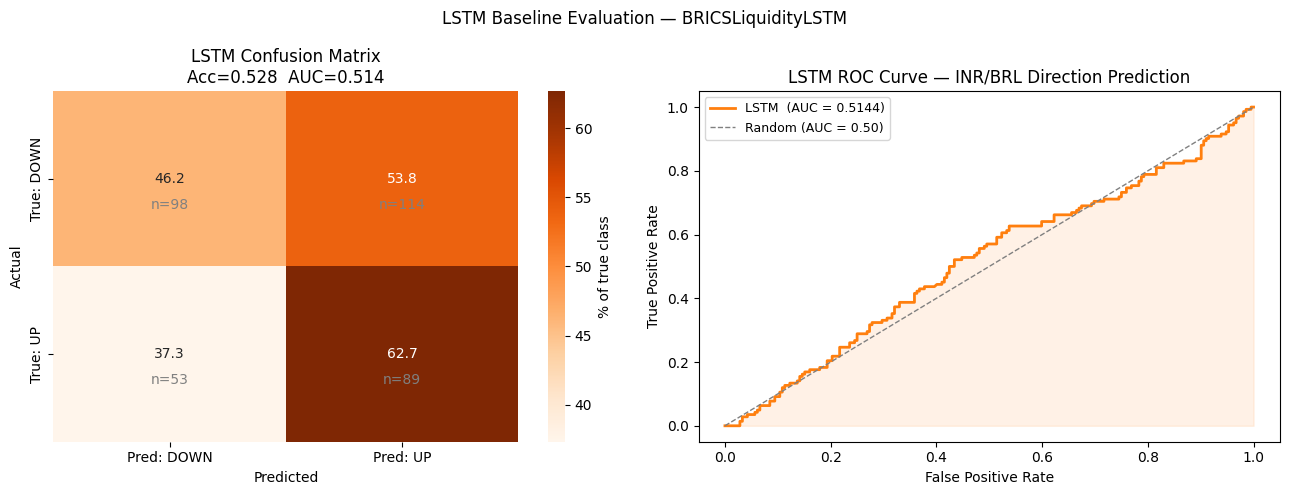

✅ Saved: outputs/lstm_confusion_matrix.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion matrix ──────────────────────────────────────────────────
ax = axes[0]
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Oranges",
    xticklabels=["Pred: DOWN", "Pred: UP"],
    yticklabels=["True: DOWN", "True: UP"],
    ax=ax, cbar_kws={"label": "% of true class"}
)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.65, f"n={cm[i,j]}",
                ha="center", va="center", fontsize=10, color="grey")
ax.set_title(f"LSTM Confusion Matrix\nAcc={acc:.3f}  AUC={auc:.3f}")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

# ── ROC curve ─────────────────────────────────────────────────────────
ax2 = axes[1]
fpr_c, tpr_c, _ = roc_curve(all_labels, all_probs)
ax2.plot(fpr_c, tpr_c, color="#ff7f0e", linewidth=2,
         label=f"LSTM  (AUC = {auc:.4f})")
ax2.plot([0, 1], [0, 1], color="grey", linestyle="--",
         linewidth=1, label="Random (AUC = 0.50)")
ax2.fill_between(fpr_c, tpr_c, alpha=0.1, color="#ff7f0e")
ax2.set_title("LSTM ROC Curve — INR/BRL Direction Prediction")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=9)

plt.suptitle("LSTM Baseline Evaluation — BRICSLiquidityLSTM", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/lstm_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/lstm_confusion_matrix.png")

#### Save training log and model

In [30]:
# ── Training log ──────────────────────────────────────────────────────
log_df   = pd.DataFrame(history)
log_path = "../outputs/lstm_training_log.csv"
log_df.to_csv(log_path, index=False)
print(f"✅ Training log : {log_path}")

# ── Model weights ─────────────────────────────────────────────────────
model_path = "../outputs/lstm_model.pth"
torch.save(lstm_model.state_dict(), model_path)
print(f"✅ Model weights: {model_path}  "
      f"({os.path.getsize(model_path)/1024:.1f} KB)")

# ── Full checkpoint ───────────────────────────────────────────────────
torch.save({
    "model_state"      : lstm_model.state_dict(),
    "val_auc"          : float(auc),
    "val_acc"          : float(acc),
    "val_f1"           : float(f1),
    "optimal_threshold": float(opt_thresh),
    "best_epoch"       : checkpoint_epoch,
    "total_train_time" : round(total_training_time, 1),
    "feature_cols"     : FEATURE_COLS,
    "config": {
        "n_features" : N_FEATURES,
        "hidden_size": 32,
        "dropout"    : 0.2,
        "num_layers" : 1,
        "lookback"   : LOOKBACK,
    },
}, "../outputs/lstm_best.pt")

# ── Config JSON ───────────────────────────────────────────────────────
lstm_config = {
    "model"            : "BRICSLiquidityLSTM",
    "n_features"       : N_FEATURES,
    "hidden_size"      : 32,
    "dropout"          : 0.2,
    "num_layers"       : 1,
    "lookback"         : LOOKBACK,
    "feature_cols"     : FEATURE_COLS,
    "val_auc"          : float(round(auc,  4)),
    "val_acc"          : float(round(acc,  4)),
    "val_f1"           : float(round(f1,   4)),
    "val_precision"    : float(round(prec, 4)),
    "val_recall"       : float(round(rec,  4)),
    "optimal_threshold": float(round(opt_thresh, 4)),
    "best_epoch"       : checkpoint_epoch,
    "total_train_time_s": round(total_training_time, 1),
    "total_epochs_trained" : len(history["epoch"]),
}

config_path = "../outputs/lstm_config.json"
with open(config_path, "w") as f:
    json.dump(lstm_config, f, indent=2)
print(f"✅ Config JSON  : {config_path}")

✅ Training log : ../outputs/lstm_training_log.csv
✅ Model weights: ../outputs/lstm_model.pth  (24.6 KB)
✅ Config JSON  : ../outputs/lstm_config.json


#### Side-by-Side comparison preview

In [31]:
# Load SNN config
with open("../outputs/snn_config.json") as f:
    snn_cfg = json.load(f)

print("=" * 68)
print("SNN vs LSTM — PRELIMINARY COMPARISON (val set)")
print("=" * 68)
print(f"\n  {'Metric':<28} {'SNN':>12}  {'LSTM':>12}  {'Winner'}")
print(f"  {'─'*60}")

def winner(snn_v, lstm_v, higher_better=True):
    if higher_better:
        return "SNN ✅" if snn_v > lstm_v else ("LSTM ✅" if lstm_v > snn_v
                                                  else "Tie")
    else:
        return "SNN ✅" if snn_v < lstm_v else ("LSTM ✅" if lstm_v < snn_v
                                                  else "Tie")

rows = [
    ("AUC-ROC",       snn_cfg["val_auc"],   auc,   True),
    ("F1 Score",      snn_cfg["val_f1"],    f1,    True),
    ("Accuracy",      snn_cfg["val_acc"],   acc,   True),
    ("Parameters",    snn_total,            lstm_total, False),
    ("Spike rate",    snn_cfg.get("spike_rate", 0.478),float("nan"), False),
    ("Energy (pJ)",   snn_energy["snn_energy_pj"] / 1000,
                      lstm_model.flops_per_inference()*0.9/1000, False),
    ("Train time (s)",snn_cfg.get("total_epochs_trained", "—"),
                      round(total_training_time, 1), False),
]

for name, snn_v, lstm_v, hb in rows:
    if isinstance(snn_v, float) and isinstance(lstm_v, float):
        w = winner(snn_v, lstm_v, hb)
        print(f"  {name:<28} {snn_v:>12.4f}  {lstm_v:>12.4f}  {w}")
    else:
        print(f"  {name:<28} {str(snn_v):>12}  {str(lstm_v):>12}")

print("=" * 68)
print("\n  Full test set comparison happens in Month 3.")
print("  This table becomes Table 2 in your thesis.")

SNN vs LSTM — PRELIMINARY COMPARISON (val set)

  Metric                                SNN          LSTM  Winner
  ────────────────────────────────────────────────────────────
  AUC-ROC                            0.5530        0.5144  SNN ✅
  F1 Score                           0.5602        0.5159  SNN ✅
  Accuracy                           0.5254        0.5282  LSTM ✅
  Parameters                           2945          5537
  Spike rate                         0.4780           nan  Tie
  Energy (pJ)                        8.9482       94.4640  SNN ✅
  Train time (s)                         47          11.8

  Full test set comparison happens in Month 3.
  This table becomes Table 2 in your thesis.
